In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(".")


.


In [24]:
happiness = pd.read_csv('/Users/yarenerdogdu/Desktop/dsa/world_happiness_combined.csv', sep=';', decimal=',')
happiness.head()

,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,7.587,8.26132,0.96240,73,0.99379,0.37289,0.23941,2015
1,2,Iceland,Western Europe,7.561,7.70416,1.00000,73,0.93884,0.54819,0.74371,2015
2,3,Denmark,Western Europe,7.527,7.84114,0.97030,70,0.96962,0.42894,0.12382,2015
3,4,Norway,Western Europe,7.522,8.63100,0.94917,71,1.00000,0.43598,0.33860,2015
4,5,Canada,North America and ANZ,7.427,7.84595,0.94322,71,0.94511,0.57560,0.40285,2015


In [27]:
import os
print(os.getcwd())
print(os.listdir())

/Users/yarenerdogdu/anaconda_projects/6b8b73ca-f325-4681-b2cb-bab59c3681b4
['dsa proje.ipynb', 'dsa.ipynb', '.ipynb_checkpoints']


In [28]:
import os
print(os.getcwd())

/Users/yarenerdogdu/anaconda_projects/6b8b73ca-f325-4681-b2cb-bab59c3681b4


In [29]:
happiness = pd.read_csv('/Users/yarenerdogdu/Desktop/dsa/world_happiness_combined.csv', sep=';', decimal=',')
print(happiness.shape)
happiness.head()

(1502, 11)


,Ranking,Country,Regional indicator,Happiness score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Year
0,1,Switzerland,Western Europe,7.587,8.26132,0.96240,73,0.99379,0.37289,0.23941,2015
1,2,Iceland,Western Europe,7.561,7.70416,1.00000,73,0.93884,0.54819,0.74371,2015
2,3,Denmark,Western Europe,7.527,7.84114,0.97030,70,0.96962,0.42894,0.12382,2015
3,4,Norway,Western Europe,7.522,8.63100,0.94917,71,1.00000,0.43598,0.33860,2015
4,5,Canada,North America and ANZ,7.427,7.84595,0.94322,71,0.94511,0.57560,0.40285,2015


In [31]:
import os
files = os.listdir('/Users/yarenerdogdu/Desktop/dsa')
for f in files:
    print(f)

.DS_Store
world_happiness_combined.csv
API_NY.GDP.PCAP.KD.ZG_DS2_en_csv_v2_376.csv
gdp_vs_happiness.png
API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv
happiness_economic_clean.csv
feature_importance.png
correlation_heatmap.png
region_happiness.png
API_NY.GDP.DEFL.KD.ZG_DS2_en_csv_v2_242.csv


In [30]:
happiness = pd.read_csv('/Users/yarenerdogdu/Desktop/dsa/world_happiness_combined.csv', sep=';', decimal=',')
gdp = pd.read_csv('/Users/yarenerdogdu/Desktop/dsa/API_NY.GDP.PCAP.KD.ZG_DS2_en_csv_v2_376.csv', skiprows=4)
inflation = pd.read_csv('/Users/yarenerdogdu/Desktop/dsa/API_NY.GDP.DEFL.KD.ZG_DS2_en_csv_v2_242.csv', skiprows=4)
unemp = pd.read_csv('/Users/yarenerdogdu/Desktop/dsa/API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_36.csv', skiprows=4)

print("Happiness:", happiness.shape)
print("GDP:", gdp.shape)
print("Inflation:", inflation.shape)
print("Unemployment:", unemp.shape)

Happiness: (1502, 11)
GDP: (266, 71)
Inflation: (266, 71)
Unemployment: (266, 71)


In [32]:
# World Bank dosyalarını wide'dan long formata çevir
def load_worldbank(df, value_name):
    year_cols = [str(y) for y in range(2015, 2025)]
    df = df[['Country Name'] + year_cols]
    df = df.melt(id_vars='Country Name', var_name='Year', value_name=value_name)
    df.columns = ['Country', 'Year', value_name]
    df['Year'] = df['Year'].astype(int)
    return df

gdp_long   = load_worldbank(gdp, 'GDP_Growth')
inf_long   = load_worldbank(inflation, 'Inflation')
unemp_long = load_worldbank(unemp, 'Unemployment')

# Happiness kolonlarını düzenle
happiness.columns = ['Ranking', 'Country', 'Region', 'Happiness_Score',
                     'GDP_per_capita', 'Social_Support', 'Healthy_Life_Expectancy',
                     'Freedom', 'Generosity', 'Corruption', 'Year']

# Hepsini birleştir
worldbank = gdp_long.merge(inf_long, on=['Country', 'Year'], how='outer')
worldbank = worldbank.merge(unemp_long, on=['Country', 'Year'], how='outer')
df = happiness.merge(worldbank, on=['Country', 'Year'], how='left')

print("Final dataset:", df.shape)
df.head()

Final dataset: (1502, 14)


,Ranking,Country,Region,Happiness_Score,GDP_per_capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption,Year,GDP_Growth,Inflation,Unemployment
0,1,Switzerland,Western Europe,7.587,8.26132,0.96240,73,0.99379,0.37289,0.23941,2015,0.494130,-1.265057,4.801
1,2,Iceland,Western Europe,7.561,7.70416,1.00000,73,0.93884,0.54819,0.74371,2015,2.692997,6.751630,3.979
2,3,Denmark,Western Europe,7.527,7.84114,0.97030,70,0.96962,0.42894,0.12382,2015,1.385666,0.409103,6.278
3,4,Norway,Western Europe,7.522,8.63100,0.94917,71,1.00000,0.43598,0.33860,2015,0.848799,-2.804468,4.296
4,5,Canada,North America and ANZ,7.427,7.84595,0.94322,71,0.94511,0.57560,0.40285,2015,-0.112369,-0.867651,6.945


In [41]:

print("Missing values:")
print(df.isnull().sum())
print(f"\nRows before cleaning: {len(df)}")


df_clean = df.dropna(subset=['GDP_Growth', 'Inflation', 'Unemployment'])
print(f"Rows after cleaning: {len(df_clean)}")


df_clean.to_csv('/Users/yarenerdogdu/Desktop/dsa/happiness_economic_clean.csv', index=False)


Missing values:
Ranking                      0
Country                      0
Region                       3
Happiness_Score              0
GDP_per_capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom                      0
Generosity                   0
Corruption                   0
Year                         0
GDP_Growth                 217
Inflation                  217
Unemployment               224
dtype: int64

Rows before cleaning: 1502
Rows after cleaning: 1272


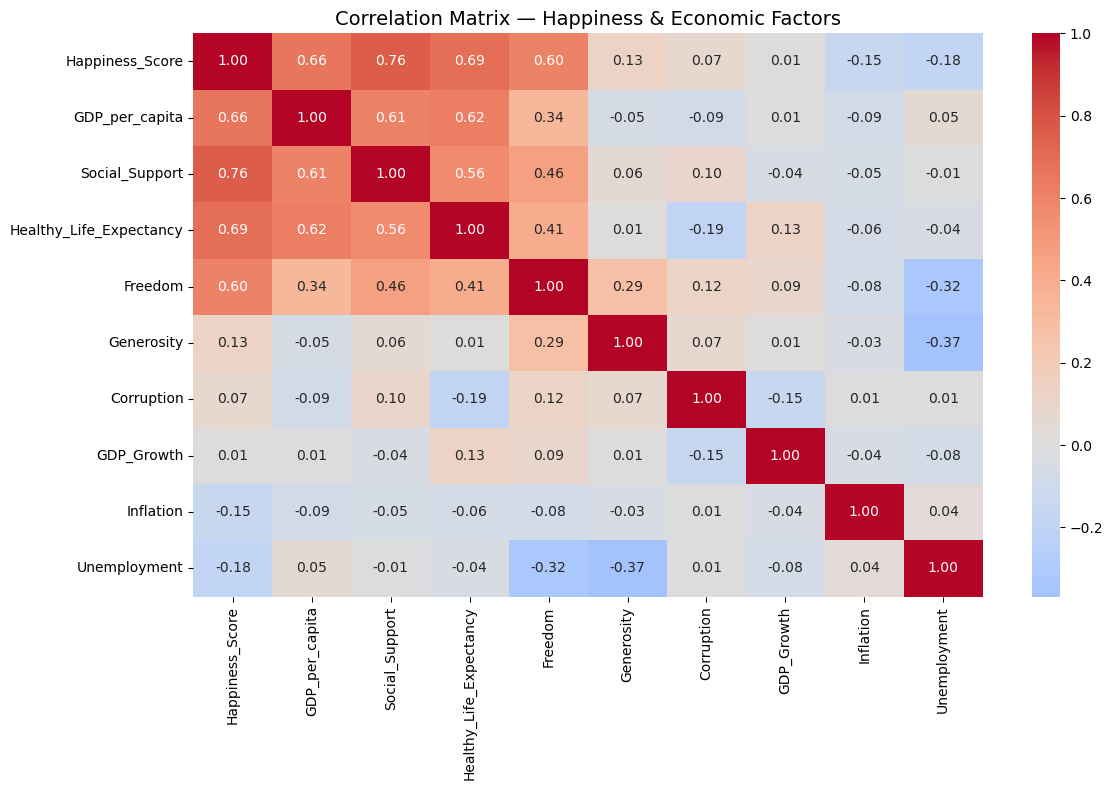

In [34]:

numeric_cols = ['Happiness_Score', 'GDP_per_capita', 'Social_Support', 
                'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 
                'Corruption', 'GDP_Growth', 'Inflation', 'Unemployment']

plt.figure(figsize=(12, 8))
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Happiness & Economic Factors', fontsize=14)
plt.tight_layout()
plt.savefig('/Users/yarenerdogdu/Desktop/dsa/correlation_heatmap.png', dpi=150)
plt.show()


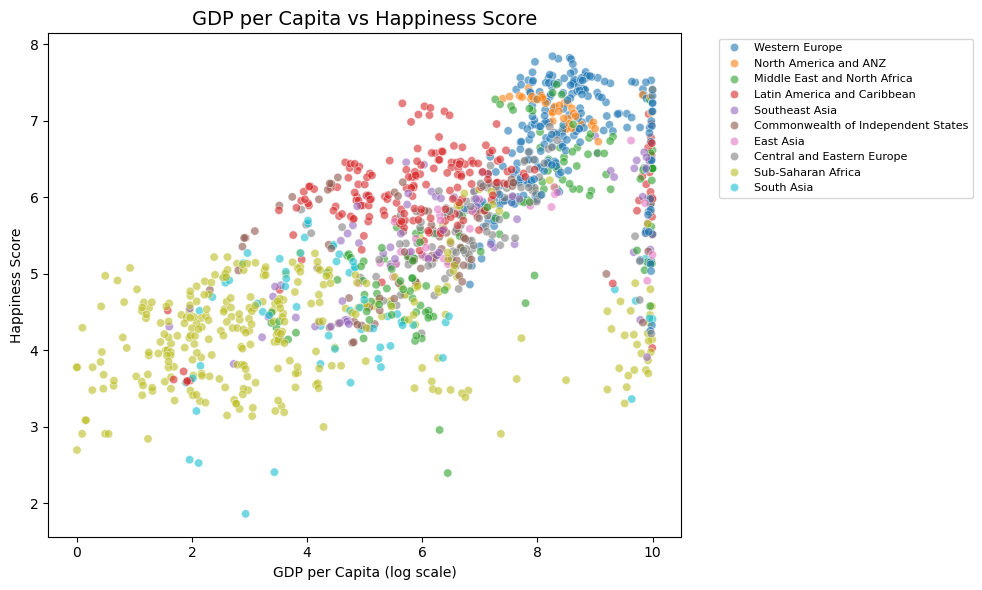

In [35]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='GDP_per_capita', y='Happiness_Score', 
                hue='Region', alpha=0.6)
plt.title('GDP per Capita vs Happiness Score', fontsize=14)
plt.xlabel('GDP per Capita (log scale)')
plt.ylabel('Happiness Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('/Users/yarenerdogdu/Desktop/dsa/gdp_vs_happiness.png', dpi=150)
plt.show()

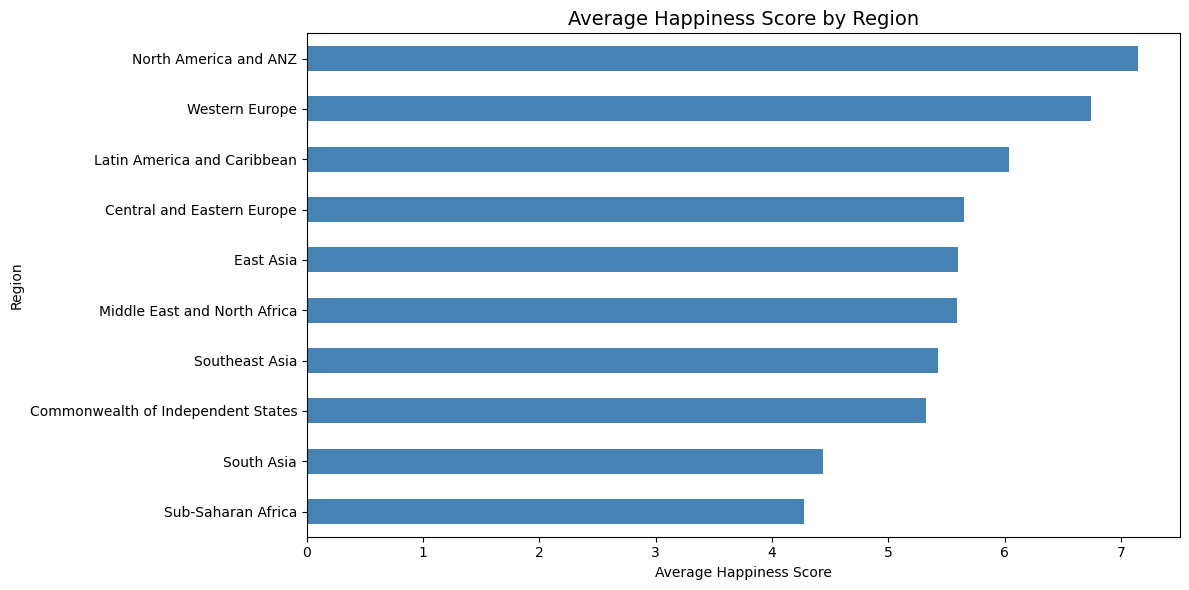

In [36]:

plt.figure(figsize=(12, 6))
region_avg = df_clean.groupby('Region')['Happiness_Score'].mean().sort_values(ascending=True)
region_avg.plot(kind='barh', color='steelblue')
plt.title('Average Happiness Score by Region', fontsize=14)
plt.xlabel('Average Happiness Score')
plt.tight_layout()
plt.savefig('/Users/yarenerdogdu/Desktop/dsa/region_happiness.png', dpi=150)
plt.show()

In [43]:
from scipy import stats


variables = ['GDP_per_capita', 'GDP_Growth', 'Inflation', 'Unemployment']

for var in variables:
    corr, pvalue = stats.pearsonr(df_clean[var].dropna(), 
                                   df_clean.loc[df_clean[var].notna(), 'Happiness_Score'])
    significance = "Significant" if pvalue < 0.05 else "Not Significant"
    print(f"{var}:")
    print(f"  Korelasyon: {corr:.3f} | p-value: {pvalue:.4f} | {significance}")
    print()

GDP_per_capita:
  Korelasyon: 0.657 | p-value: 0.0000 | Significant

GDP_Growth:
  Korelasyon: 0.012 | p-value: 0.6727 | Not Significant

Inflation:
  Korelasyon: -0.149 | p-value: 0.0000 | Significant

Unemployment:
  Korelasyon: -0.180 | p-value: 0.0000 | Significant



In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

features = ['GDP_per_capita', 'GDP_Growth', 'Inflation', 'Unemployment',
            'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 'Corruption']

X = df_clean[features].dropna()
y = df_clean.loc[X.index, 'Happiness_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
rf_r2 = r2_score(y_test, rf_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Linear Regression R2:", round(lr_r2, 3), "MAE:", round(lr_mae, 3))
print("Random Forest R2:", round(rf_r2, 3), "MAE:", round(rf_mae, 3))

Linear Regression R2: 0.742 MAE: 0.451
Random Forest R2: 0.821 MAE: 0.348
